In [ ]:
# ==========================
# 1. Install dependencies
# ==========================
!pip install tensorflow streamlit pillow numpy scikit-learn matplotlib
# ==========================

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 93.8 MB/s eta 0:00:00


In [ ]:

# 2. Mount Google Drive (optional, to save models)
# ==========================
from google.colab import drive
drive.mount('/content/drive')

# ==========================

Mounted at /content/drive


In [ ]:

# 3. Import libraries
# ==========================
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# ==========================

In [ ]:

# 4. Upload dataset ZIP
# ==========================
from google.colab import files

print("Please upload dataset.zip (must contain folders: glioma, meningioma, pituitary, no_tumor)")
uploaded = files.upload()

zip_path = list(uploaded.keys())[0]
dataset_dir = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

print("✅ Dataset extracted to:", dataset_dir)

# ==========================

Please upload dataset.zip (must contain folders: glioma, meningioma, pituitary, no_tumor)


Saving Brain Tumor f.zip to Brain Tumor f.zip
✅ Dataset extracted to: /content/dataset


In [ ]:


# 5. Data generators
# ==========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_gen = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

num_classes = train_gen.num_classes
class_indices = train_gen.class_indices
print("Detected classes:", class_indices) # ==========================

Found 5619 images belonging to 2 classes.
Found 1404 images belonging to 2 classes.
Detected classes: {'Testing': 0, 'Training': 1}


In [ ]:

# 6. Build Transfer Learning model
# ==========================
base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
x = base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base.input, outputs=output)

for layer in base.layers:
    layer.trainable = False

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()



# ==========================

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:

# 7. Callbacks
# ==========================
ckpt_path = "/content/brain_tumor_mobilenetv2.h5"
callbacks = [
    ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

# ==========================

In [ ]:
# 8. Training
# ==========================
EPOCHS = 10
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("✅ Training complete. Model saved to", ckpt_path)

# ==========================

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.7622 - loss: 0.5870
Epoch 1: val_accuracy improved from -inf to 0.79345, saving model to /content/brain_tumor_mobilenetv2.h5


352/352 ━━━━━━━━━━━━━━━━━━━━ 195s 543ms/step - accuracy: 0.7622 - loss: 0.5870 - val_accuracy: 0.7934 - val_loss: 0.5267 - learning_rate: 0.0010
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7891 - loss: 0.5341
Epoch 2: val_accuracy improved from 0.79345 to 0.81339, saving model to /content/brain_tumor_mobilenetv2.h5


352/352 ━━━━━━━━━━━━━━━━━━━━ 202s 545ms/step - accuracy: 0.7891 - loss: 0.5340 - val_accuracy: 0.8134 - val_loss: 0.5123 - learning_rate: 0.0010
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.8035 - loss: 0.4849
Epoch 3: val_accuracy did not improve from 0.81339
352/352 ━━━━━━━━━━━━━━━━━━━━ 202s 544ms/step - accuracy: 0.8035 - loss: 0.4849 - val_accuracy: 0.8127 - val_loss: 0.5364 - learning_rate: 0.0010
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8026 - loss: 0.4994
Epoch 4: val_accuracy did not improve from 0.81339

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
352/352 ━━━━━━━━━━━━━━━━━━━━ 210s 568ms/step - accuracy: 0.8026 - loss: 0.4994 - val_accuracy: 0.8134 - val_loss: 0.5447 - learning_rate: 0.0010
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.8098 - loss: 0.4862
Epoch 5: val_accuracy did not improve from 0.81339
352/352 ━━━━━━━━━━━━━━━━━━━━ 196s 556ms/step - accuracy: 0.8098 - loss:

In [ ]:

# 9. Evaluate model
# ==========================
val_loss, val_acc = model.evaluate(val_gen)
print(f"Validation Accuracy: {val_acc:.2%} | Validation Loss: {val_loss:.4f}")

# ==========================

88/88 ━━━━━━━━━━━━━━━━━━━━ 39s 437ms/step - accuracy: 0.5091 - loss: 1.0865
Validation Accuracy: 81.34% | Validation Loss: 0.5155


In [ ]:

# 10. Save to Drive (optional)
# ==========================
drive_path = "/content/drive/MyDrive/brain_tumor_mobilenetv2.h5"
!cp {ckpt_path} {drive_path}
print("Model copied to Google Drive:", drive_path)

# ==========================

Model copied to Google Drive: /content/drive/MyDrive/brain_tumor_mobilenetv2.h5


In [ ]:
import os

print(os.listdir("/content"))          # to check what is inside /content
print(os.listdir("/content/dataset"))  # to check inside dataset folder


['.config', 'dataset', 'Brain Tumor f.zip', 'brain_tumor_mobilenetv2.h5', 'drive', 'sample_data']
['Testing', 'Training']


In [ ]:
import os

files = sorted(os.listdir("/content/dataset/Testing"))
print(files)


['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
import os
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load your trained model
model = load_model("/content/brain_tumor_mobilenetv2.h5")

# Dataset directory
dataset_dir = "/content/dataset/Testing"

# Classes (subfolders) in Testing
subfolders = os.listdir(dataset_dir)
print("Available Classes:", subfolders)

# Pick one class (for example 'notumor') and one image
chosen_class = "notumor"   # 🔑 change if you want another class
img_path = os.path.join(dataset_dir, chosen_class, os.listdir(os.path.join(dataset_dir, chosen_class))[0])
print("Picked Image:", img_path)

# Prediction function
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))  # MobileNetV2 input size
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)[0]

    class_labels = subfolders  # folder names will be the labels
    print("Predicted:", class_labels[predicted_class])

# Run prediction
predict_image(img_path)


Available Classes: ['glioma', 'meningioma', 'pituitary', 'notumor']
Picked Image: /content/dataset/Testing/notumor/Te-no_0090.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step
Predicted: meningioma


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(4, activation="softmax")(x)   # 4 classes

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


143/143 ━━━━━━━━━━━━━━━━━━━━ 547s 4s/step - accuracy: 0.8624 - loss: 0.4150 - val_accuracy: 0.4040 - val_loss: 16.1983
Epoch 2/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 520s 4s/step - accuracy: 0.9319 - loss: 0.1958 - val_accuracy: 0.3111 - val_loss: 7.9534
Epoch 3/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 520s 4s/step - accuracy: 0.9568 - loss: 0.1310 - val_accuracy: 0.3111 - val_loss: 16.4408
Epoch 4/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 521s 4s/step - accuracy: 0.9753 - loss: 0.0671 - val_accuracy: 0.2340 - val_loss: 24.9247
Epoch 5/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 521s 4s/step - accuracy: 0.9710 - loss: 0.0822 - val_accuracy: 0.3970 - val_loss: 8.3631


Found 1311 images belonging to 4 classes.
41/41 ━━━━━━━━━━━━━━━━━━━━ 28s 687ms/step - accuracy: 0.3428 - loss: 11.1050
Test Accuracy: 0.4546147882938385
Test Loss: 7.352272987365723
41/41 ━━━━━━━━━━━━━━━━━━━━ 31s 726ms/step
Classification Report:
               precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       300
  meningioma       0.35      0.96      0.51       306
     notumor       0.60      0.57      0.58       405
   pituitary       1.00      0.24      0.39       300

    accuracy                           0.45      1311
   macro avg       0.49      0.44      0.37      1311
weighted avg       0.49      0.45      0.39      1311



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


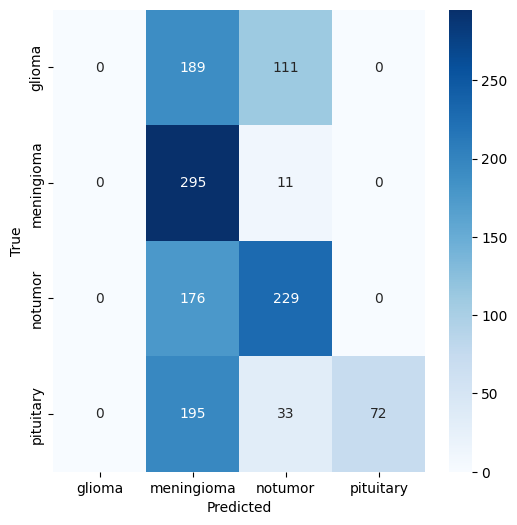

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step


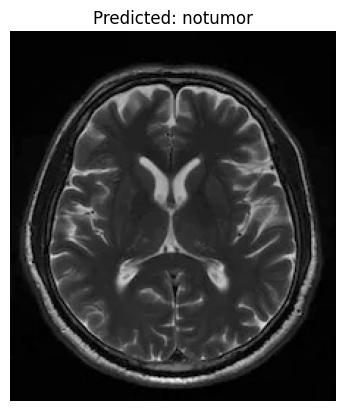

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import random
from tensorflow.keras.preprocessing import image

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    "/content/dataset/Training",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    "/content/dataset/Training",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

# Save model
model.save("/content/brain_tumor_mobilenetv2_4class.h5")

# --- Step 3: Evaluate on Testing ---
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "/content/dataset/Testing",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# Evaluate
loss, acc = model.evaluate(test_generator)
print("Test Accuracy:", acc)
print("Test Loss:", loss)

# Predictions
y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_generator.classes
labels = list(test_generator.class_indices.keys())

# Classification report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Show random prediction
def show_prediction(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    predicted_class = np.argmax(pred, axis=1)[0]
    label = labels[predicted_class]

    plt.imshow(image.load_img(img_path))
    plt.title(f"Predicted: {label}")
    plt.axis("off")
    plt.show()

# Pick random test image
test_class = random.choice(labels)
img_file = random.choice(os.listdir(f"/content/dataset/Testing/{test_class}"))
img_path = f"/content/dataset/Testing/{test_class}/{img_file}"
show_prediction(img_path)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "/content/dataset/Training",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "/content/dataset/Testing",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [ ]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',   # val_loss monitor pannum
    patience=3,           # 3 epochs continuous ah improv illa na stop
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]   # Add panniruken
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 703s 4s/step - accuracy: 0.9146 - loss: 0.2626 - val_accuracy: 0.6384 - val_loss: 1.8966
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 705s 4s/step - accuracy: 0.9510 - loss: 0.1529 - val_accuracy: 0.2563 - val_loss: 10.1402
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 708s 4s/step - accuracy: 0.9660 - loss: 0.0970 - val_accuracy: 0.3272 - val_loss: 11.0681
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 741s 4s/step - accuracy: 0.9562 - loss: 0.1383 - val_accuracy: 0.3463 - val_loss: 5.5072


In [ ]:
# Evaluate on the test dataset
loss, acc = model.evaluate(test_generator)
print("Test Accuracy:", acc)
print("Test Loss:", loss)


41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 911ms/step - accuracy: 0.7414 - loss: 0.6525
Test Accuracy: 0.8115941882133484
Test Loss: 0.4973437786102295


41/41 ━━━━━━━━━━━━━━━━━━━━ 31s 731ms/step


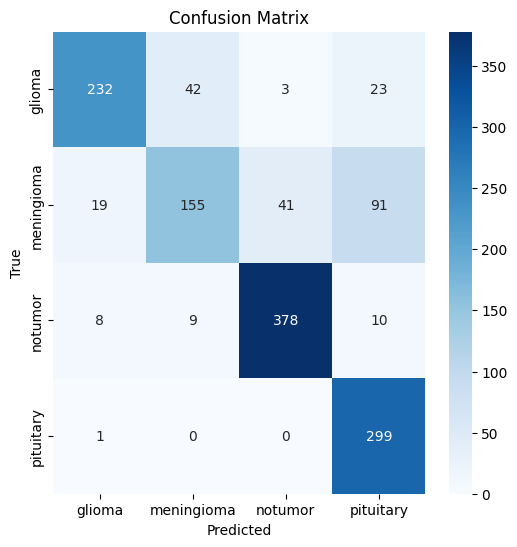

Classification Report:

              precision    recall  f1-score   support

      glioma       0.89      0.77      0.83       300
  meningioma       0.75      0.51      0.61       306
     notumor       0.90      0.93      0.91       405
   pituitary       0.71      1.00      0.83       300

    accuracy                           0.81      1311
   macro avg       0.81      0.80      0.79      1311
weighted avg       0.82      0.81      0.80      1311



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Predict test set
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Step 2: True labels
y_true = test_generator.classes

# Step 3: Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Step 4: Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))


In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ReduceLROnPlateau → learning rate reduce pannum if no improvement
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,      # LR reduce 20% ah
    patience=2,      # 2 epochs improv illa na reduce
    min_lr=1e-6      # minimum LR
)

# Fine-tuning train
history_finetune = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.6887 - loss: 0.9270 - val_accuracy: 0.7941 - val_loss: 0.5728 - learning_rate: 1.0000e-05
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.8194 - loss: 0.4862 - val_accuracy: 0.8131 - val_loss: 0.5742 - learning_rate: 1.0000e-05
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.8502 - loss: 0.4021 - val_accuracy: 0.8330 - val_loss: 0.5254 - learning_rate: 1.0000e-05
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.8567 - loss: 0.3873 - val_accuracy: 0.8444 - val_loss: 0.4922 - learning_rate: 1.0000e-05
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.8770 - loss: 0.3647 - val_accuracy: 0.8551 - val_loss: 0.4489 - learning_rate: 1.0000e-05
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.8884 - loss: 0.3171 - val_accuracy: 0.8711 - val_loss: 0.3963 - learning_rate: 1.0000e-05
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - acc

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9040 - loss: 0.2627 - val_accuracy: 0.9047 - val_loss: 0.2691 - learning_rate: 1.0000e-05
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.9238 - loss: 0.2072 - val_accuracy: 0.9115 - val_loss: 0.2504 - learning_rate: 1.0000e-05
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.9215 - loss: 0.2086 - val_accuracy: 0.9108 - val_loss: 0.2347 - learning_rate: 1.0000e-05
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.9289 - loss: 0.1904 - val_accuracy: 0.9191 - val_loss: 0.2215 - learning_rate: 1.0000e-05
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.9347 - loss: 0.1916 - val_accuracy: 0.9230 - val_loss: 0.2001 - learning_rate: 1.0000e-05
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.9412 - loss: 0.1659 - val_accuracy: 0.9283 - val_loss: 0.1836 - learning_rate: 1.0000e-05
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - acc

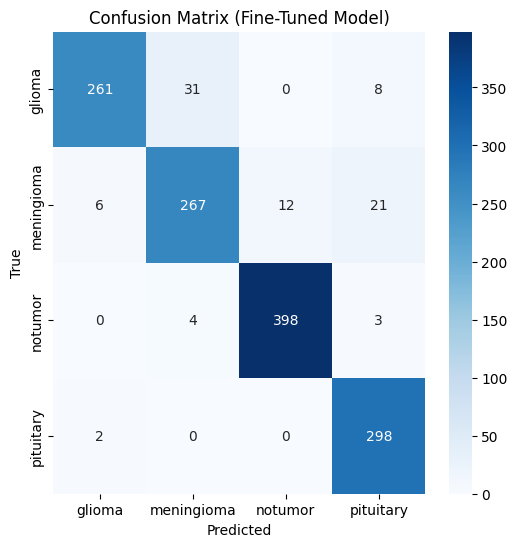

Classification Report (Fine-Tuned Model):

              precision    recall  f1-score   support

      glioma       0.97      0.87      0.92       300
  meningioma       0.88      0.87      0.88       306
     notumor       0.97      0.98      0.98       405
   pituitary       0.90      0.99      0.95       300

    accuracy                           0.93      1311
   macro avg       0.93      0.93      0.93      1311
weighted avg       0.93      0.93      0.93      1311



In [ ]:
# =========================================
# Step 1: Unfreeze last few layers
# =========================================
base_model.trainable = True

# Freeze first ~120 layers (keep ImageNet features)
for layer in base_model.layers[:120]:
    layer.trainable = False

# =========================================
# Step 2: Re-compile model with small LR
# =========================================
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),   # very small LR
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================================
# Step 3: Train (Fine-tuning phase)
# =========================================
history_finetune = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

# =========================================
# Step 4: Evaluate again
# =========================================
loss, acc = model.evaluate(test_generator)
print("Fine-Tuned Test Accuracy:", acc)
print("Fine-Tuned Test Loss:", loss)

# =========================================
# Step 5: Confusion Matrix + Report
# =========================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Fine-Tuned Model)")
plt.show()

# Classification Report
print("Classification Report (Fine-Tuned Model):\n")
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))


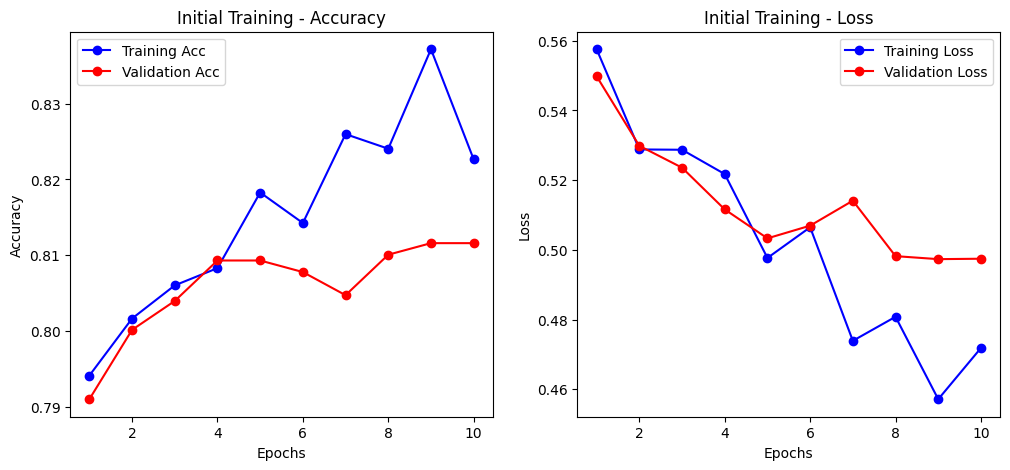

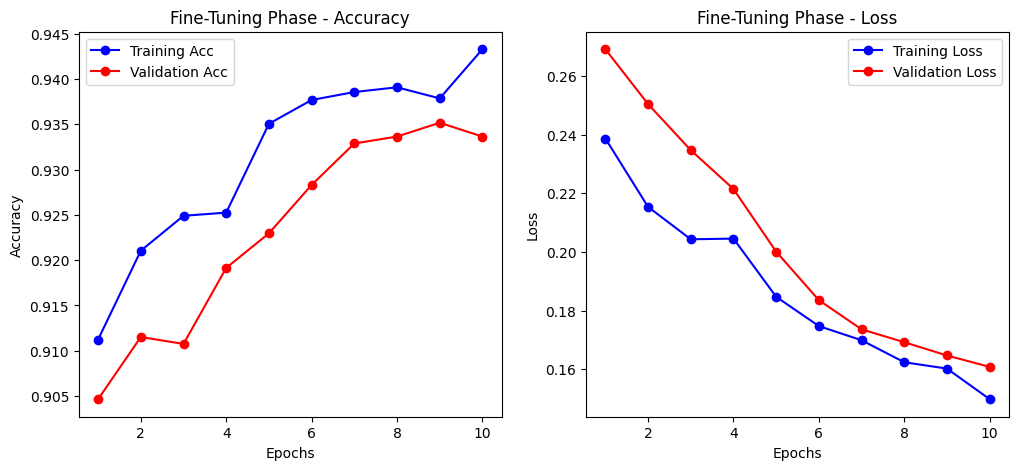

In [ ]:
import matplotlib.pyplot as plt

# ==========================
# Function to plot training history
# ==========================
def plot_history(history, title="Model Training"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# ==========================
# Plot Initial Training
# ==========================
plot_history(history, "Initial Training")

# ==========================
# Plot Fine-Tuning Training
# ==========================
plot_history(history_finetune, "Fine-Tuning Phase")


In [ ]:
import cv2
import numpy as np
from PIL import Image

# Overlay Heatmap on Original Image
def overlay_heatmap(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    # Heatmap to 0-255 range
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap
    heatmap = cv2.applyColorMap(heatmap, colormap)

    # Convert original PIL image to OpenCV format
    img = np.array(img)

    # Resize heatmap same size as original
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Overlay heatmap on image
    overlayed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

    # Convert back to PIL for easy viewing
    return Image.fromarray(overlayed_img)


In [ ]:
img_path = "/content/dataset/Testing/glioma/Te-gl_0010.jpg"

img_array, original_img = get_img_array(img_path, size=(224,224))

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="Conv_1")

overlayed_img = overlay_heatmap(original_img, heatmap)

overlayed_img.show()


In [ ]:
from keras.applications import MobileNetV2
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D, Dropout
from keras.optimizers import Adam

# Base model (pretrained)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False   # freeze base layers

# Custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)   # 4 classes

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.3341 - loss: 1.6305 - val_accuracy: 0.5843 - val_loss: 0.9798
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.5397 - loss: 1.1231 - val_accuracy: 0.6873 - val_loss: 0.8050
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.6138 - loss: 0.9449 - val_accuracy: 0.7285 - val_loss: 0.7116
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.6786 - loss: 0.8060 - val_accuracy: 0.7330 - val_loss: 0.6805
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.7080 - loss: 0.7433 - val_accuracy: 0.7559 - val_loss: 0.6468
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.7368 - loss: 0.6726 - val_accuracy: 0.7574 - val_loss: 0.6295
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.7528 - loss: 0.6430 - val_accuracy: 0.7597 - val_loss: 0.6191
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.7708 - loss: 0.6170 - val_accu

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_labels = list(train_generator.class_indices.keys())
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# Train with class weights
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)


Class Weights: {0: np.float64(1.080999242997729), 1: np.float64(1.0664675130694548), 2: np.float64(0.8952978056426333), 3: np.float64(0.9800960878517502)}
Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.7825 - loss: 0.5756 - val_accuracy: 0.7742 - val_loss: 0.5778
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.7959 - loss: 0.5495 - val_accuracy: 0.7864 - val_loss: 0.5525
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.8046 - loss: 0.5351 - val_accuracy: 0.7879 - val_loss: 0.5339
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.8185 - loss: 0.4917 - val_accuracy: 0.7864 - val_loss: 0.5555
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.8128 - loss: 0.4981 - val_accuracy: 0.7948 - val_loss: 0.5263
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.8156 - loss: 0.4931 - val_accuracy: 0.7948 - val_loss: 0.5303
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.8077

In [ ]:
import zipfile
import os

# Replace with your uploaded ZIP file name
zip_path = "/content/Brain Tumor f.zip"
extract_dir = "/content/brain_tumor_dataset"

# Extract the ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Check extracted files
print(os.listdir(extract_dir))


['Testing', 'Training']


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Function to predict custom image
def predict_custom_image_4class(img_path):
    img = image.load_img(img_path, target_size=(224, 224))  # same size used while training
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # normalize

    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction, axis=1)[0]

    class_labels = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']  # training la use panra labels order

    return class_labels[class_idx]

# Example usage
custom_image_path = "/content/dataset/Testing/glioma/Te-gl_0010.jpg"
predicted_label = predict_custom_image_4class(custom_image_path)
print("Predicted Tumor Type:", predicted_label)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step
Predicted Tumor Type: Glioma


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step


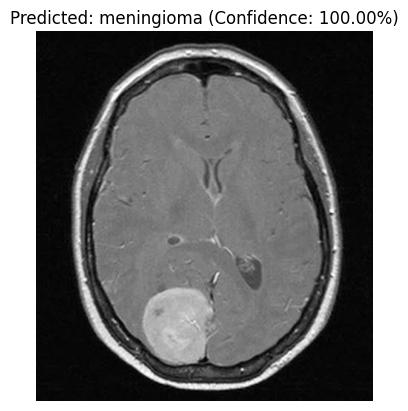

Predicted Tumor Type: meningioma


In [ ]:
import cv2
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# Load trained 4-class model
from tensorflow.keras.models import load_model
model_4class = load_model("/content/brain_tumor_mobilenetv2_4class.h5")

# Class labels for the 4-class model
labels_4class = ['glioma', 'meningioma', 'notumor', 'pituitary'] # Updated based on classification report

# Function to predict single image using the 4-class model
def predict_custom_image_4class(img_path):
    """
    Predicts the tumor type of a single image using the 4-class model.

    Args:
        img_path (str): Path to the image file.

    Returns:
        str: Predicted tumor type label.
    """
    if not os.path.exists(img_path):
        print(f"Error: Image file not found at {img_path}")
        return None

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model_4class.predict(img_array)
    predicted_class_index = np.argmax(pred, axis=1)[0]
    predicted_label = labels_4class[predicted_class_index]
    confidence = pred[0][predicted_class_index]


    plt.imshow(image.load_img(img_path))
    plt.title(f"Predicted: {predicted_label} (Confidence: {confidence:.2%})")
    plt.axis("off")
    plt.show()

    return predicted_label

# Example usage:
# Replace the path below with the actual path to your MRI image file in Colab.
# You can upload an image or use one from your Google Drive or extracted dataset.
custom_image_path = "/content/dataset/Testing/meningioma/Te-me_0010.jpg" # Example path, replace with your image path
predicted_label = predict_custom_image_4class(custom_image_path)

if predicted_label:
    print("Predicted Tumor Type:", predicted_label)

In [ ]:
# Example: Pick any test image from the 'Testing' directory
# Ensure you have the dataset extracted at /content/dataset/Testing
test_dataset_dir = dataset_dir   # FIXED: no extra "Testing"

if os.path.exists(test_dataset_dir):
    # Get a list of all subfolders (original class names) in Testing
    test_subfolders = os.listdir(test_dataset_dir)
    if test_subfolders:
        # Pick the first subfolder (e.g., 'glioma')
        sample_class_folder = test_subfolders[0]
        sample_class_path = os.path.join(test_dataset_dir, sample_class_folder)

        if os.path.exists(sample_class_path):
            # Pick the first image in that subfolder
            images_in_folder = os.listdir(sample_class_path)
            if images_in_folder:
                test_img_path = os.path.join(sample_class_path, images_in_folder[0])
                print(f"Testing with image: {test_img_path}")
                predict_image(test_img_path, model, class_indices)
            else:
                print(f"No images found in {sample_class_path}")
        else:
            print(f"Subfolder not found: {sample_class_path}")
    else:
        print(f"No subfolders found in {test_dataset_dir}")
else:
    print(f"Testing dataset directory not found: {test_dataset_dir}")


Testing with image: /content/dataset/Testing/glioma/Te-gl_0161.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted class: Training (Confidence: 47.00%)


In [ ]:
!pip install streamlit pyngrok


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================
# Load model
# ==========================
MODEL_PATH = "/content/brain_tumor_mobilenetv2_4class.h5"

@st.cache_resource
def load_my_model():
    return load_model(MODEL_PATH)

model = load_my_model()
LABELS = ['glioma', 'meningioma', 'notumor', 'pituitary']

# ==========================
# Grad-CAM function
# ==========================
def get_gradcam(img_array, model, class_index, last_conv_layer_name="Conv_1"):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap(img, heatmap, alpha=0.4, colormap=plt.cm.jet):
    import cv2
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = colormap(heatmap)
    heatmap = np.uint8(255 * heatmap[:, :, :3])
    overlayed = cv2.addWeighted(np.array(img), 1-alpha, heatmap, alpha, 0)
    return overlayed

# ==========================
# Streamlit UI
# ==========================
st.title("Brain Tumor Classification")
st.write("Upload an MRI image to classify the type of brain tumor.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg","jpeg","png"])

if uploaded_file is not None:
    img = image.load_img(uploaded_file, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    st.image(img, caption="Uploaded Image", use_container_width=True)

    # Prediction
    if model:
        predictions = model.predict(img_array)
        idx = np.argmax(predictions, axis=1)[0]
        predicted_label = LABELS[idx]
        confidence = predictions[0][idx]

        if predicted_label == "notumor":
            st.success("Tumor Present? No")
        else:
            st.success("Tumor Present? Yes")
            st.info(f"Tumor Type: {predicted_label}")

        st.info(f"Confidence: {confidence:.2%}")

        # ==========================
        # Grad-CAM visualization
        # ==========================
        if predicted_label != "notumor":
            st.write("Generating Grad-CAM...")
            heatmap = get_gradcam(img_array, model, idx)
            overlayed_img = overlay_heatmap(img, heatmap)
            st.image(overlayed_img, caption="Grad-CAM Heatmap", use_container_width=True)
    else:
        st.error("Model not loaded. Cannot make prediction.")


Overwriting app.py


This code creates a simple Streamlit application with the following features:
-   Loads the trained 4-class model.
-   Provides a file uploader for users to submit an image.
-   Displays the uploaded image.
-   Uses the loaded model to predict the tumor type (or no tumor).
-   Shows the predicted class and confidence score.

The code is saved to a file named `app.py` using the `%%writefile` magic command.

Now that the Streamlit script is created, the next step according to the plan is to install `pyngrok`.

In [ ]:
from pyngrok import ngrok

# Add your ngrok authtoken (only once)
!ngrok config add-authtoken 31ViNQHcXZQxmzvoUfoOD8xUagW_7ybpdjTkdHvhAK4JNrojN


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!pkill ngrok


In [ ]:
from pyngrok import ngrok

# Only the token string, NOT the command
NGROK_AUTHTOKEN = "31ViNQHcXZQxmzvoUfoOD8xUagW_7ybpdjTkdHvhAK4JNrojN"

!pkill ngrok  # stop previous ngrok tunnels
!ngrok config add-authtoken {NGROK_AUTHTOKEN}  # register token

# Run Streamlit in background
!streamlit run app.py --server.port 8501 &>/dev/null&

# Connect and get public URL
public_url = ngrok.connect(8501)
print("🌍 Open your app here:", public_url)


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
🌍 Open your app here: NgrokTunnel: "https://8b70286c8de9.ngrok-free.app" -> "http://localhost:8501"
